# Master Notebook for Edge Classification (Branch Congestion)
This master notebook trains and compares multiple Graph Neural Network architectures (GCN, GraphSAGE, GAT, MPNN, ECGNN, PINN) to predict congestion across the branches of the IEEE 57-bus grid.

In [2]:
import importlib.util
import subprocess, sys

required_packages = [
    "pandas>=2.2.3",
    "pandapower",
    "numpy",
    "torch",
    "torchvision",
    "torchaudio",
    "torch_geometric",
    "h5py",
    "optuna",
    "matplotlib",
]

if importlib.util.find_spec("pip") is None:
    raise RuntimeError(
        "pip is not available in this notebook kernel. Select the project virtual environment kernel "
        "or install python3-pip in WSL before running this cell."
    )

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required_packages])

0

In [3]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split, WeightedRandomSampler
import pandapower.networks as nw

1. PyTorch Geometric Dataset

In [ ]:
import os
import sys

def ensure_project_root():
    in_colab = "google.colab" in sys.modules

    if in_colab:
        from google.colab import drive
        drive_root = "/content/drive"
        if not os.path.exists(drive_root):
            drive.mount(drive_root)

    candidate_roots = [
        os.environ.get("CSML_PROJECT_ROOT"),
        os.getcwd(),
        os.path.join(os.getcwd(), "nodal-gnn"),
        "/content/nodal-gnn",
        "/content/CSML/nodal-gnn",
        "/content/drive/MyDrive/CSML/nodal-gnn",
        "/content/drive/MyDrive/MASTER_AI/CASE STUDIES MACHINE LEARNING/CSML/nodal-gnn",
    ]

    for root in candidate_roots:
        if not root:
            continue
        ieee_dataset_path = os.path.join(root, "ieee_dataset.py")
        models_init_path = os.path.join(root, "models", "__init__.py")
        if os.path.exists(ieee_dataset_path) and os.path.exists(models_init_path):
            if root not in sys.path:
                sys.path.insert(0, root)
            os.chdir(root)
            print(f"Using project root: {root}")
            return root

    checked = "\n".join(f"- {path}" for path in candidate_roots if path)
    raise FileNotFoundError(
        "Unable to locate the nodal-gnn project folder. Place the full project in Colab or Google Drive, "
        f"or set CSML_PROJECT_ROOT. Checked:\n{checked}"
    )

project_root = ensure_project_root()

from ieee_dataset import IEEECongestionCSVDataset

def resolve_csv_path():
    dataset_name = "congestion_dataset_v5.csv"
    windows_drive_parts = [
        "My Drive",
        "MASTER_AI",
        "CASE STUDIES MACHINE LEARNING",
        "final_project_data",
        dataset_name,
    ]

    colab_drive_parts = [
        "/content",
        "drive",
        "MyDrive",
        "MASTER_AI",
        "CASE STUDIES MACHINE LEARNING",
        "final_project_data",
        dataset_name,
    ]

    candidates = [
        os.environ.get("CONGESTION_DATASET_PATH"),
        os.path.join(os.environ["CSML_DATA_DIR"], dataset_name) if "CSML_DATA_DIR" in os.environ else None,
        os.path.join(*colab_drive_parts),
        os.path.join("G:\\", *windows_drive_parts),
        os.path.join(os.path.expanduser("~"), *windows_drive_parts),
        os.path.join(os.path.expanduser("~"), "Google Drive", *windows_drive_parts),
        os.path.join(project_root, dataset_name),
        os.path.join(os.getcwd(), dataset_name),
    ]

    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate

    checked = "\n".join(f"- {path}" for path in candidates if path)
    raise FileNotFoundError(f"Unable to locate {dataset_name}. Checked:\n{checked}")

csv_path = resolve_csv_path()
print(f"Using dataset CSV: {csv_path}")
dataset = IEEECongestionCSVDataset(csv_path)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
 )

# --- WeightedRandomSampler: oversample congested scenarios ---
cong_cols = dataset.df.iloc[:, 171:]  # 80 congestion target columns
has_congestion = (cong_cols.sum(axis=1) > 0).values  # True if any branch congested

train_indices = train_dataset.indices
train_labels = has_congestion[train_indices]
n_pos = train_labels.sum()
n_neg = len(train_labels) - n_pos
weight_pos = len(train_labels) / (2 * n_pos + 1e-8)
weight_neg = len(train_labels) / (2 * n_neg + 1e-8)
sample_weights = torch.tensor(
    [weight_pos if lbl else weight_neg for lbl in train_labels],
    dtype=torch.float64
 )
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True)
print(f"Congested samples in train: {n_pos}/{len(train_labels)} ({100*n_pos/len(train_labels):.2f}%)")
print(f"Sample weights - pos: {weight_pos:.1f}, neg: {weight_neg:.1f}")

train_loader = DataLoader(train_dataset, batch_size=256, sampler=train_sampler)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dataset: {len(dataset)} samples  (train={train_size}, val={val_size}, test={test_size})")
print(f"Using device: {device}")

ModuleNotFoundError: No module named 'ieee_dataset'

2. Hyperparameter Tuning (Optuna)

Quick search (few epochs per trial) to find optimal hyperparameters for each model.

In [ ]:
from models.gcn_model import GCNEdgePredictor
from models.graphsage_model import GraphSAGEEdgePredictor
from models.gat_model import GATEdgePredictor
from models.mpnn_model import MPNNEdgePredictor
from models.ecgnn_model import ECGNNEdgePredictor
from models.pinn_model import PINNEdgePredictor
import pickle
import optuna

MODEL_TYPES = ['GCN', 'GraphSAGE', 'GAT', 'MPNN', 'ECGNN', 'PINN']
MODEL_TYPES = ['GraphSAGE', 'GAT', 'MPNN', 'ECGNN']

model_classes = {
    'GCN': GCNEdgePredictor,
    'GraphSAGE': GraphSAGEEdgePredictor,
    'GAT': GATEdgePredictor,
    'MPNN': MPNNEdgePredictor,
    'ECGNN': ECGNNEdgePredictor,
    'PINN': PINNEdgePredictor
}

IN_CHANNELS = 6       # Pd, Qd, gen_status, pgmax, pgmin, degree_centrality
NUM_EDGE_FEATS = 3    # smax, branch_status, susceptance (b)

OPTUNA_EPOCHS = 5
OPTUNA_TRIALS = 15  # Increase for a more thorough search

best_hyperparams = {}

for TUNE_MODEL in MODEL_TYPES:
    print(f"\n{'='*50}")
    print(f"Tuning hyperparameters for {TUNE_MODEL}...")
    print(f"{'='*50}")

    OptunaModelClass = model_classes[TUNE_MODEL]

    def objective(trial):
        hidden_channels = trial.suggest_categorical("hidden_channels", [32, 64, 128])
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.4)
        pw_value = trial.suggest_float("pos_weight", 1.0, 50.0, log=True)

        tune_train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
        tune_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        trial_model = OptunaModelClass(
            in_channels=IN_CHANNELS,
            hidden_channels=hidden_channels,
            branch_u=dataset.branch_u,
            branch_v=dataset.branch_v,
            dropout_rate=dropout_rate,
            num_edge_feats=NUM_EDGE_FEATS,
        ).to(device)

        opt = torch.optim.Adam(trial_model.parameters(), lr=lr)
        pos_w = torch.tensor([pw_value]).to(device)
        crit = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_w)

        for epoch in range(OPTUNA_EPOCHS):
            trial_model.train()
            for batch in tune_train_loader:
                batch = batch.to(device)
                opt.zero_grad()
                out = trial_model(batch)
                y = batch.y.view(-1, 1)
                mask = batch.status.view(-1, 1)
                loss = (crit(out, y) * mask).sum() / (mask.sum() + 1e-8)
                loss.backward()
                opt.step()

        trial_model.eval()
        tp, fp, fn = 0, 0, 0
        with torch.no_grad():
            for batch in tune_val_loader:
                batch = batch.to(device)
                out = trial_model(batch)
                y = batch.y.view(-1, 1)
                mask = batch.status.view(-1, 1)
                preds = (out > 0).float()
                masked_preds = preds * mask
                masked_y = y * mask
                tp += ((masked_preds == 1) & (masked_y == 1)).float().sum().item()
                fp += ((masked_preds == 1) & (masked_y == 0)).float().sum().item()
                fn += ((masked_preds == 0) & (masked_y == 1)).float().sum().item()
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        return f1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=OPTUNA_TRIALS)
    print(f"\nBest val F1 for {TUNE_MODEL}: {study.best_value:.4f}")
    print(f"Best params for {TUNE_MODEL}: {study.best_params}")

    best_hyperparams[TUNE_MODEL] = {
        'best_val_f1': study.best_value,
        'params': study.best_params
    }

print("\n\n--- OPTUNA RESULTS SUMMARY ---")
for model_name, info in best_hyperparams.items():
    print(f"{model_name} (F1: {info['best_val_f1']:.4f})  Params: {info['params']}")


Tuning hyperparameters for GraphSAGE...


[I 2026-04-10 17:53:11,907] A new study created in memory with name: no-name-938961ce-892c-45ca-9155-875ad0affcc4
[I 2026-04-10 18:00:34,613] Trial 0 finished with value: 0.5428429872664076 and parameters: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.00020299380505940827, 'dropout_rate': 0.11022410062286654, 'pos_weight': 1.7293729205537045}. Best is trial 0 with value: 0.5428429872664076.
[I 2026-04-10 18:06:43,648] Trial 1 finished with value: 0.43733729650460584 and parameters: {'hidden_channels': 64, 'batch_size': 512, 'lr': 0.0012220056261358118, 'dropout_rate': 0.07699304486595492, 'pos_weight': 3.721072605130034}. Best is trial 0 with value: 0.5428429872664076.
[I 2026-04-10 18:15:08,982] Trial 2 finished with value: 0.18273809352866713 and parameters: {'hidden_channels': 128, 'batch_size': 512, 'lr': 0.0006143045408684381, 'dropout_rate': 0.2201856171273219, 'pos_weight': 19.848948650979832}. Best is trial 0 with value: 0.5428429872664076.
[I 2026-04-10 18:23:09,487] Tria


Best val F1 for GraphSAGE: 0.7310
Best params for GraphSAGE: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.009315006183165123, 'dropout_rate': 0.03670301811258727, 'pos_weight': 1.3238040487743243}

Tuning hyperparameters for GAT...


[I 2026-04-10 19:54:38,841] A new study created in memory with name: no-name-a47e620a-160f-4c48-a2aa-a1c4ad22910b
[I 2026-04-10 20:05:49,458] Trial 0 finished with value: 0.6407263245918435 and parameters: {'hidden_channels': 64, 'batch_size': 128, 'lr': 0.001042288847902257, 'dropout_rate': 0.19890116552381487, 'pos_weight': 1.3151032622356744}. Best is trial 0 with value: 0.6407263245918435.
[I 2026-04-10 20:15:03,917] Trial 1 finished with value: 0.1956561395844766 and parameters: {'hidden_channels': 64, 'batch_size': 512, 'lr': 0.0002756081544028333, 'dropout_rate': 0.19709800078980266, 'pos_weight': 1.3461888484441464}. Best is trial 0 with value: 0.6407263245918435.
[I 2026-04-10 20:24:40,701] Trial 2 finished with value: 0.2464454953578399 and parameters: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.00042082259669368925, 'dropout_rate': 0.2570870786851862, 'pos_weight': 5.827949666197971}. Best is trial 0 with value: 0.6407263245918435.
[I 2026-04-10 20:40:48,793] Trial 3 


Best val F1 for GAT: 0.8256
Best params for GAT: {'hidden_channels': 128, 'batch_size': 512, 'lr': 0.0015849373905746133, 'dropout_rate': 0.0038298691122543305, 'pos_weight': 3.3731315095748067}

Tuning hyperparameters for MPNN...


[I 2026-04-10 22:45:23,882] A new study created in memory with name: no-name-88c9ee2f-29dd-49b9-a95f-63155baf7d84
[I 2026-04-10 22:51:47,114] Trial 0 finished with value: 0.21822962074431534 and parameters: {'hidden_channels': 32, 'batch_size': 512, 'lr': 0.0015345351078260446, 'dropout_rate': 0.39067311247067366, 'pos_weight': 1.8845704779235422}. Best is trial 0 with value: 0.21822962074431534.
[I 2026-04-10 22:59:35,326] Trial 1 finished with value: 0.16913946431088933 and parameters: {'hidden_channels': 64, 'batch_size': 512, 'lr': 0.0036847696005939956, 'dropout_rate': 0.16151184024134335, 'pos_weight': 30.61444409269638}. Best is trial 0 with value: 0.21822962074431534.
[I 2026-04-10 23:10:44,142] Trial 2 finished with value: 0.35342639272316434 and parameters: {'hidden_channels': 128, 'batch_size': 512, 'lr': 0.0002823645732910361, 'dropout_rate': 0.03663211702304903, 'pos_weight': 2.5435764335862836}. Best is trial 2 with value: 0.35342639272316434.
[I 2026-04-10 23:17:08,838] 


Best val F1 for MPNN: 0.8270
Best params for MPNN: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.0017168251993236075, 'dropout_rate': 0.05864874670703544, 'pos_weight': 1.3807207407223896}

Tuning hyperparameters for ECGNN...


[I 2026-04-11 01:16:03,210] A new study created in memory with name: no-name-69efa314-cee9-40fc-9cb5-582fe8585ed9
[I 2026-04-11 01:41:52,778] Trial 0 finished with value: 0.7432762788624829 and parameters: {'hidden_channels': 128, 'batch_size': 128, 'lr': 0.000800933040126323, 'dropout_rate': 0.008548299656637948, 'pos_weight': 3.3060685299296444}. Best is trial 0 with value: 0.7432762788624829.
[I 2026-04-11 01:57:23,843] Trial 1 finished with value: 0.7032448330671263 and parameters: {'hidden_channels': 64, 'batch_size': 256, 'lr': 0.0002509686436780675, 'dropout_rate': 0.15521952322978141, 'pos_weight': 2.7730042438129514}. Best is trial 0 with value: 0.7432762788624829.
[I 2026-04-11 02:22:07,562] Trial 2 finished with value: 0.7074500255451812 and parameters: {'hidden_channels': 128, 'batch_size': 256, 'lr': 0.008501432904100215, 'dropout_rate': 0.08736895794577296, 'pos_weight': 2.3320282793553493}. Best is trial 0 with value: 0.7432762788624829.
[I 2026-04-11 02:48:21,658] Trial


Best val F1 for ECGNN: 0.8189
Best params for ECGNN: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.004170366771869414, 'dropout_rate': 0.05532770724480458, 'pos_weight': 1.6711076653792523}


--- OPTUNA RESULTS SUMMARY ---
GraphSAGE (F1: 0.7310)  Params: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.009315006183165123, 'dropout_rate': 0.03670301811258727, 'pos_weight': 1.3238040487743243}
GAT (F1: 0.8256)  Params: {'hidden_channels': 128, 'batch_size': 512, 'lr': 0.0015849373905746133, 'dropout_rate': 0.0038298691122543305, 'pos_weight': 3.3731315095748067}
MPNN (F1: 0.8270)  Params: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.0017168251993236075, 'dropout_rate': 0.05864874670703544, 'pos_weight': 1.3807207407223896}
ECGNN (F1: 0.8189)  Params: {'hidden_channels': 32, 'batch_size': 128, 'lr': 0.004170366771869414, 'dropout_rate': 0.05532770724480458, 'pos_weight': 1.6711076653792523}


3. Full Training with Optimal Hyperparameters

Train each model for 100 epochs using the best hyperparameters found by Optuna, then evaluate on the test set and save to `models/trained/`.

In [ ]:
TRAINED_DIR = os.path.join("models", "trained")
os.makedirs(TRAINED_DIR, exist_ok=True)

epochs = 200
all_histories = {}
all_test_metrics = {}

for m_type in MODEL_TYPES:
    params = best_hyperparams[m_type]['params']
    print(f"\n{'='*40}\nTraining {m_type} with optimal params\n{'='*40}")
    print(f"  hidden={params['hidden_channels']}, lr={params['lr']:.5f}, "
          f"dropout={params['dropout_rate']:.3f}, pos_weight={params['pos_weight']:.2f}, "
          f"batch_size={params['batch_size']}")

    ModelClass = model_classes[m_type]

    model = ModelClass(
        in_channels=IN_CHANNELS,
        hidden_channels=params['hidden_channels'],
        branch_u=dataset.branch_u,
        branch_v=dataset.branch_v,
        dropout_rate=params['dropout_rate'],
        num_edge_feats=NUM_EDGE_FEATS,
    ).to(device)

    train_ldr = DataLoader(train_dataset, batch_size=params['batch_size'], sampler=train_sampler)
    val_ldr   = DataLoader(val_dataset,   batch_size=params['batch_size'], shuffle=False)
    test_ldr  = DataLoader(test_dataset,  batch_size=params['batch_size'], shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    pos_weight = torch.tensor([params['pos_weight']]).to(device)
    criterion = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight)

    history = {"epoch": [], "train_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # --- Train ---
        model.train()
        total_loss, n_batches = 0.0, 0
        for batch in train_ldr:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            y = batch.y.view(-1, 1)
            mask = batch.status.view(-1, 1)
            loss = (criterion(out, y) * mask).sum() / (mask.sum() + 1e-8)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        avg_loss = total_loss / n_batches

        # --- Validate ---
        model.eval()
        correct, total_active = 0, 0
        v_tp, v_fp, v_fn = 0, 0, 0
        with torch.no_grad():
            for batch in val_ldr:
                batch = batch.to(device)
                out = model(batch)
                y = batch.y.view(-1, 1)
                mask = batch.status.view(-1, 1)
                preds = (out > 0).float()
                masked_preds = preds * mask
                masked_y = y * mask
                correct += ((preds == y).float() * mask).sum().item()
                total_active += mask.sum().item()
                v_tp += ((masked_preds == 1) & (masked_y == 1)).float().sum().item()
                v_fp += ((masked_preds == 1) & (masked_y == 0)).float().sum().item()
                v_fn += ((masked_preds == 0) & (masked_y == 1)).float().sum().item()
        val_acc = correct / total_active
        val_prec = v_tp / (v_tp + v_fp + 1e-8) if v_tp + v_fp > 0 else 0
        val_rec = v_tp / (v_tp + v_fn + 1e-8) if v_tp + v_fn > 0 else 0

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)

        if epoch % 5 == 0 or epoch == epochs:
            print(f"Epoch {epoch:3d}/{epochs} | loss={avg_loss:.4f} | val_acc={val_acc:.4f} | precision={val_prec:.4f} | recall={val_rec:.4f}")

    all_histories[m_type] = history

    # --- Test ---
    model.eval()
    correct, total_active = 0, 0
    tp, fp, fn = 0, 0, 0
    with torch.no_grad():
        for batch in test_ldr:
            batch = batch.to(device)
            out = model(batch)
            y = batch.y.view(-1, 1)
            mask = batch.status.view(-1, 1)
            preds = (out > 0).float()
            masked_preds = preds * mask
            masked_y = y * mask
            correct += ((preds == y).float() * mask).sum().item()
            total_active += mask.sum().item()
            tp += ((masked_preds == 1) & (masked_y == 1)).float().sum().item()
            fp += ((masked_preds == 1) & (masked_y == 0)).float().sum().item()
            fn += ((masked_preds == 0) & (masked_y == 1)).float().sum().item()

    test_acc = correct / total_active if total_active > 0 else 0
    precision = tp / (tp + fp + 1e-8) if tp + fp > 0 else 0
    recall = tp / (tp + fn + 1e-8) if tp + fn > 0 else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-8) if precision + recall > 0 else 0

    all_test_metrics[m_type] = {
        "acc": test_acc, "precision": precision, "recall": recall, "f1": f1
    }
    print(f"Test Accuracy: {test_acc:.4f} | F1: {f1:.4f}")

    # --- Save model ---
    save_path = os.path.join(TRAINED_DIR, f"{m_type}.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(model.cpu().state_dict(), f)
    model.to(device)
    print(f"Model saved to {save_path}")


Training GraphSAGE with optimal params
  hidden=32, lr=0.00932, dropout=0.037, pos_weight=1.32, batch_size=128
Epoch   5/200 | loss=0.0045 | val_acc=0.9991 | precision=0.5300 | recall=0.9748
Epoch  10/200 | loss=0.0029 | val_acc=0.9984 | precision=0.3912 | recall=0.9558
Epoch  15/200 | loss=0.0026 | val_acc=0.9995 | precision=0.6943 | recall=0.9495
Epoch  20/200 | loss=0.0025 | val_acc=0.9997 | precision=0.8198 | recall=0.8896
Epoch  25/200 | loss=0.0020 | val_acc=0.9991 | precision=0.5548 | recall=0.9338
Epoch  30/200 | loss=0.0019 | val_acc=0.9993 | precision=0.6020 | recall=0.9732
Epoch  35/200 | loss=0.0018 | val_acc=0.9983 | precision=0.3780 | recall=0.8580
Epoch  40/200 | loss=0.0018 | val_acc=0.9993 | precision=0.6144 | recall=0.9274
Epoch  45/200 | loss=0.0016 | val_acc=0.9995 | precision=0.6758 | recall=0.9732
Epoch  50/200 | loss=0.0017 | val_acc=0.9998 | precision=0.8605 | recall=0.9148
Epoch  55/200 | loss=0.0016 | val_acc=0.9995 | precision=0.6707 | recall=0.9669
Epoch  6

In [ ]:

# --- PINN-specific Optuna tuning ---
PINN_OPTUNA_EPOCHS = 5
PINN_OPTUNA_TRIALS = 15

print(f"{'='*50}")
print(f"Tuning hyperparameters for PINN...")
print(f"{'='*50}")

def pinn_objective(trial):
    hidden_channels = trial.suggest_categorical("hidden_channels", [32, 64, 128])
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.4)
    pw_value = trial.suggest_float("pos_weight", 1.0, 50.0, log=True)

    tune_train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    tune_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    trial_model = PINNEdgePredictor(
        in_channels=IN_CHANNELS,
        hidden_channels=hidden_channels,
        branch_u=dataset.branch_u,
        branch_v=dataset.branch_v,
        dropout_rate=dropout_rate,
        num_edge_feats=NUM_EDGE_FEATS,
    ).to(device)

    opt = torch.optim.Adam(trial_model.parameters(), lr=lr)
    pos_w = torch.tensor([pw_value]).to(device)
    crit = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_w)

    for epoch in range(PINN_OPTUNA_EPOCHS):
        trial_model.train()
        for batch in tune_train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            out = trial_model(batch)
            y = batch.y.view(-1, 1)
            mask = batch.status.view(-1, 1)
            loss = (crit(out, y) * mask).sum() / (mask.sum() + 1e-8)
            loss.backward()
            opt.step()

    trial_model.eval()
    tp, fp, fn = 0, 0, 0
    with torch.no_grad():
        for batch in tune_val_loader:
            batch = batch.to(device)
            out = trial_model(batch)
            y = batch.y.view(-1, 1)
            mask = batch.status.view(-1, 1)
            preds = (out > 0).float()
            masked_preds = preds * mask
            masked_y = y * mask
            tp += ((masked_preds == 1) & (masked_y == 1)).float().sum().item()
            fp += ((masked_preds == 1) & (masked_y == 0)).float().sum().item()
            fn += ((masked_preds == 0) & (masked_y == 1)).float().sum().item()
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return f1

pinn_study = optuna.create_study(direction="maximize")
pinn_study.optimize(pinn_objective, n_trials=PINN_OPTUNA_TRIALS)
print(f"\nBest val F1 for PINN: {pinn_study.best_value:.4f}")
print(f"Best params for PINN: {pinn_study.best_params}")

best_hyperparams['PINN'] = {
    'best_val_f1': pinn_study.best_value,
    'params': pinn_study.best_params
}

Tuning hyperparameters for PINN...


[I 2026-04-13 08:26:24,800] A new study created in memory with name: no-name-074db59f-d713-4c7e-b4b8-ab04ed0ae1de


In [ ]:
pinn_params = best_hyperparams['PINN']['params']
pinn_epochs = 200

print(f"{'='*40}\nTraining PINN with optimal params\n{'='*40}")
print(f"  hidden={pinn_params['hidden_channels']}, lr={pinn_params['lr']:.5f}, "
      f"dropout={pinn_params['dropout_rate']:.3f}, pos_weight={pinn_params['pos_weight']:.2f}, "
      f"batch_size={pinn_params['batch_size']}")

pinn_model = PINNEdgePredictor(
    in_channels=IN_CHANNELS,
    hidden_channels=pinn_params['hidden_channels'],
    branch_u=dataset.branch_u,
    branch_v=dataset.branch_v,
    dropout_rate=pinn_params['dropout_rate'],
    num_edge_feats=NUM_EDGE_FEATS,
).to(device)

pinn_train_ldr = DataLoader(train_dataset, batch_size=pinn_params['batch_size'], sampler=train_sampler)
pinn_val_ldr   = DataLoader(val_dataset,   batch_size=pinn_params['batch_size'], shuffle=False)
pinn_test_ldr  = DataLoader(test_dataset,  batch_size=pinn_params['batch_size'], shuffle=False)

pinn_optimizer = torch.optim.Adam(pinn_model.parameters(), lr=pinn_params['lr'])
pinn_pos_weight = torch.tensor([pinn_params['pos_weight']]).to(device)
pinn_criterion = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pinn_pos_weight)

pinn_history = {"epoch": [], "train_loss": [], "val_acc": []}

for epoch in range(1, pinn_epochs + 1):
    # --- Train ---
    pinn_model.train()
    total_loss, n_batches = 0.0, 0
    for batch in pinn_train_ldr:
        batch = batch.to(device)
        pinn_optimizer.zero_grad()
        out = pinn_model(batch)
        y = batch.y.view(-1, 1)
        mask = batch.status.view(-1, 1)
        loss = (pinn_criterion(out, y) * mask).sum() / (mask.sum() + 1e-8)
        loss.backward()
        pinn_optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    avg_loss = total_loss / n_batches

    # --- Validate ---
    pinn_model.eval()
    correct, total_active = 0, 0
    v_tp, v_fp, v_fn = 0, 0, 0
    with torch.no_grad():
        for batch in pinn_val_ldr:
            batch = batch.to(device)
            out = pinn_model(batch)
            y = batch.y.view(-1, 1)
            mask = batch.status.view(-1, 1)
            preds = (out > 0).float()
            masked_preds = preds * mask
            masked_y = y * mask
            correct += ((preds == y).float() * mask).sum().item()
            total_active += mask.sum().item()
            v_tp += ((masked_preds == 1) & (masked_y == 1)).float().sum().item()
            v_fp += ((masked_preds == 1) & (masked_y == 0)).float().sum().item()
            v_fn += ((masked_preds == 0) & (masked_y == 1)).float().sum().item()
    val_acc = correct / total_active
    val_prec = v_tp / (v_tp + v_fp + 1e-8) if v_tp + v_fp > 0 else 0
    val_rec = v_tp / (v_tp + v_fn + 1e-8) if v_tp + v_fn > 0 else 0

    pinn_history["epoch"].append(epoch)
    pinn_history["train_loss"].append(avg_loss)
    pinn_history["val_acc"].append(val_acc)

    if epoch % 5 == 0 or epoch == pinn_epochs:
        print(f"Epoch {epoch:3d}/{pinn_epochs} | loss={avg_loss:.4f} | val_acc={val_acc:.4f} | precision={val_prec:.4f} | recall={val_rec:.4f}")

# --- Append to existing histories ---
all_histories['PINN'] = pinn_history

# --- Test ---
pinn_model.eval()
correct, total_active = 0, 0
tp, fp, fn = 0, 0, 0
with torch.no_grad():
    for batch in pinn_test_ldr:
        batch = batch.to(device)
        out = pinn_model(batch)
        y = batch.y.view(-1, 1)
        mask = batch.status.view(-1, 1)
        preds = (out > 0).float()
        masked_preds = preds * mask
        masked_y = y * mask
        correct += ((preds == y).float() * mask).sum().item()
        total_active += mask.sum().item()
        tp += ((masked_preds == 1) & (masked_y == 1)).float().sum().item()
        fp += ((masked_preds == 1) & (masked_y == 0)).float().sum().item()
        fn += ((masked_preds == 0) & (masked_y == 1)).float().sum().item()

test_acc = correct / total_active if total_active > 0 else 0
precision = tp / (tp + fp + 1e-8) if tp + fp > 0 else 0
recall = tp / (tp + fn + 1e-8) if tp + fn > 0 else 0
f1 = 2 * precision * recall / (precision + recall + 1e-8) if precision + recall > 0 else 0

# --- Append to existing test metrics ---
all_test_metrics['PINN'] = {
    "acc": test_acc, "precision": precision, "recall": recall, "f1": f1
}
print(f"\nPINN Test Accuracy: {test_acc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

# --- Save model ---
save_path = os.path.join(TRAINED_DIR, "PINN.pkl")
with open(save_path, "wb") as f:
    pickle.dump(pinn_model.cpu().state_dict(), f)
pinn_model.to(device)
print(f"Model saved to {save_path}")

# --- Show updated comparison ---
print("\n--- Updated Test Set Results (all models) ---")
metrics_df = pd.DataFrame(all_test_metrics).T
metrics_df = metrics_df[['acc', 'f1', 'precision', 'recall']]
display(metrics_df.sort_values(by='f1', ascending=False))

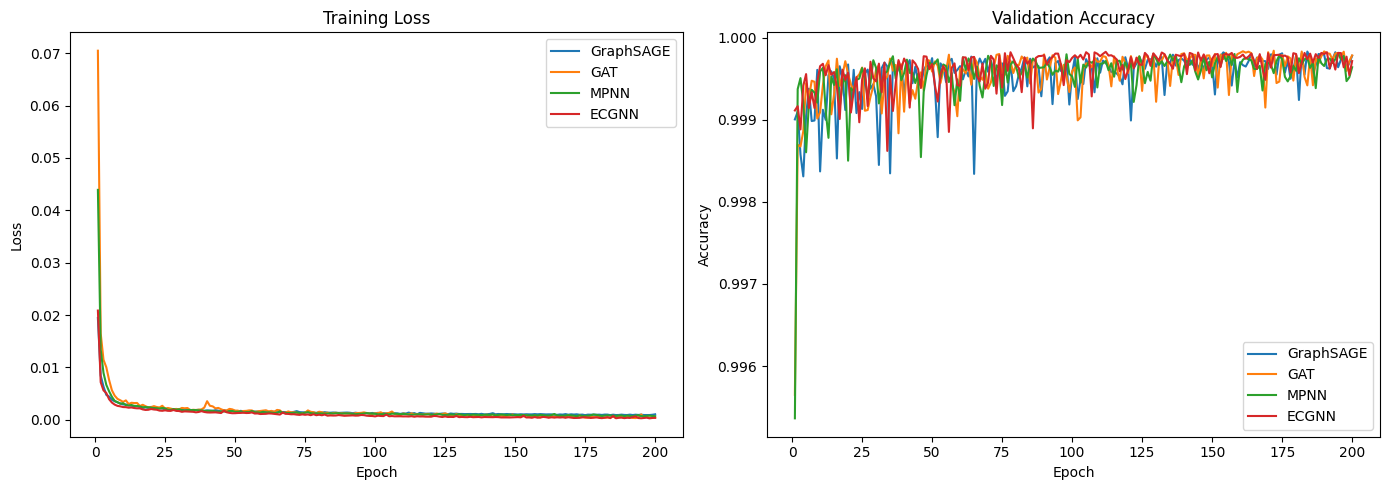


--- Test Set Results (trained with Optuna-tuned hyperparameters) ---


,acc,f1,precision,recall
GAT,0.999815,0.913249,0.866766,0.965000
ECGNN,0.999789,0.902477,0.842486,0.971667
GraphSAGE,0.999804,0.901928,0.907251,0.896667
MPNN,0.999698,0.866270,0.781501,0.971667


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for m_type, hist in all_histories.items():
    ax1.plot(hist["epoch"], hist["train_loss"], label=m_type)
    ax2.plot(hist["epoch"], hist["val_acc"], label=m_type)

ax1.set(xlabel="Epoch", ylabel="Loss", title="Training Loss")
ax1.legend()
ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Validation Accuracy")
ax2.legend()
fig.tight_layout()
plt.show()

print("\n--- Test Set Results (trained with Optuna-tuned hyperparameters) ---")
metrics_df = pd.DataFrame(all_test_metrics).T
metrics_df = metrics_df[['acc', 'f1', 'precision', 'recall']]
display(metrics_df.sort_values(by='f1', ascending=False))